In [1]:
# %% Cell 1 - Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
from pathlib import Path

# display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
sns.set(style="whitegrid")
OUTPUT_DIR = Path("eda_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [7]:
# %% Cell 2 - Load data
csv_path = "supermarket.csv" 
df = pd.read_csv(csv_path)
from io import StringIO



print("Loaded rows:", len(df))
df.head()

Loaded rows: 1000


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [24]:
# %% Cell 3 - Basic info
# df.info()
# df.describe(include='all').T

# %% Cell 4 - Check for missing values
dups = df.duplicated().sum()
print("Duplicate rows:", dups)


# Check missing values
print("Missing values per column:\n", df.isnull().sum())

# Convert Date and Time columns
df['Date'] = pd.to_datetime(df['Date'])
# Ensure the 'Time' column is in a consistent format
df['Time'] = pd.to_datetime(df['Time'], errors='coerce', format='%H:%M:%S').dt.time

# Check for any rows where 'Time' could not be converted
invalid_times = df['Time'].isna().sum()
if invalid_times > 0:
	print(f"Warning: {invalid_times} rows have invalid time formats and were set to NaT.")




Duplicate rows: 0
Missing values per column:
 Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64


In [26]:
# Extract new time features
df['Month'] = df['Date'].dt.month_name()
df['Day'] = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.day_name()


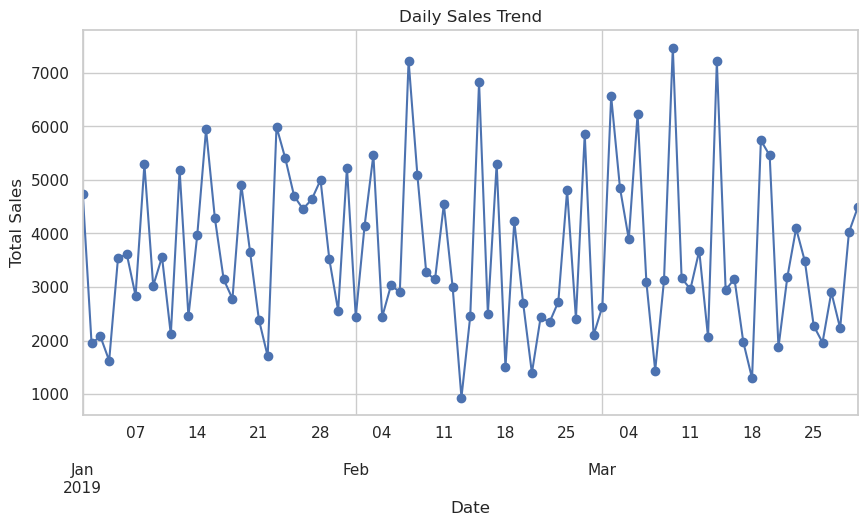

In [32]:
# Sales over time
daily_sales = df.groupby('Date')['Total'].sum()

plt.figure(figsize=(10,5))
daily_sales.plot(kind='line', marker='o')
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()


/tmp/ipykernel_48380/3733384427.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Hour', data=df, palette="coolwarm")


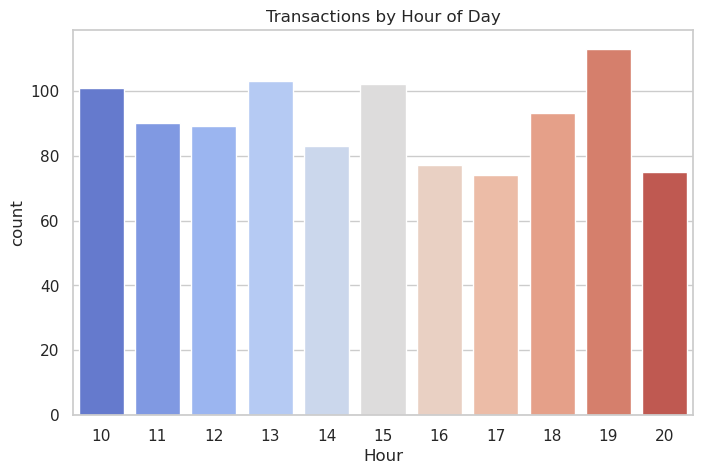

In [34]:
# Sales by hour of the day
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S').apply(lambda x: x.hour)

plt.figure(figsize=(8,5))
sns.countplot(x='Hour', data=df, palette="coolwarm")
plt.title("Transactions by Hour of Day")
plt.show()



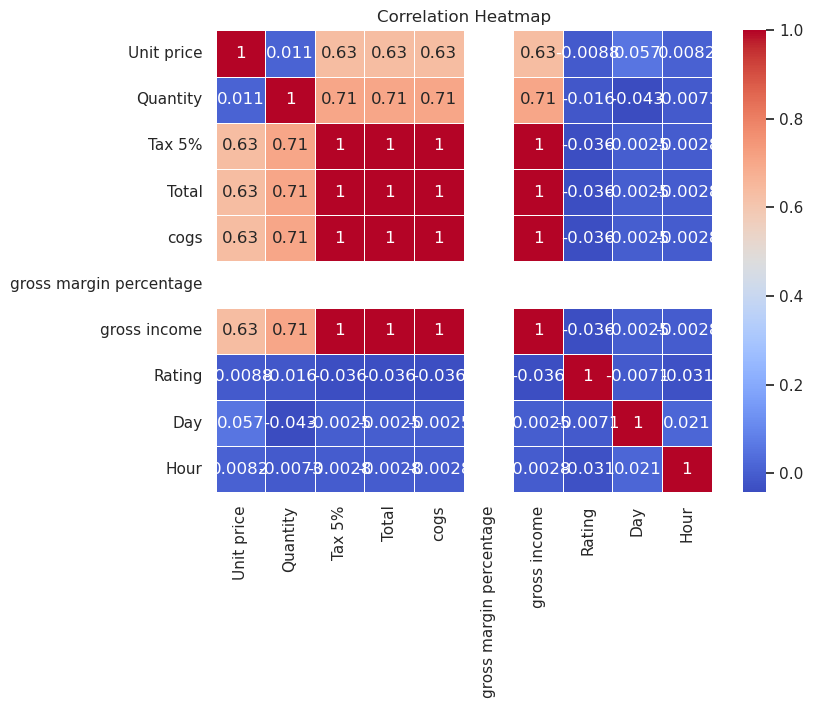

In [36]:
plt.figure(figsize=(8,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


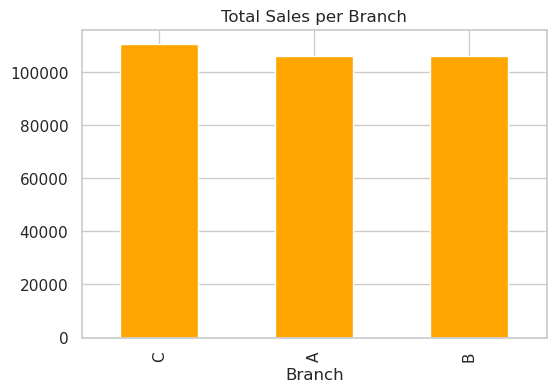

In [38]:
branch_sales = df.groupby('Branch')['Total'].sum().sort_values(ascending=False)
branch_sales.plot(kind='bar', color='orange', figsize=(6,4), title='Total Sales per Branch')
plt.show()


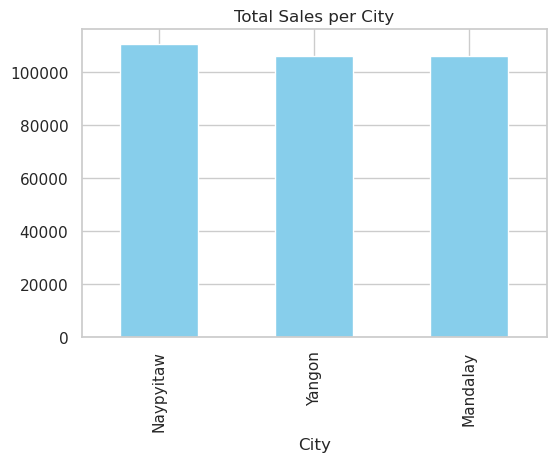

In [40]:
city_sales = df.groupby('City')['Total'].sum().sort_values(ascending=False)
city_sales.plot(kind='bar', color='skyblue', figsize=(6,4), title='Total Sales per City')
plt.show()


/tmp/ipykernel_48380/2850000648.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Payment', data=df, order=df['Payment'].value_counts().index, palette="Set2")


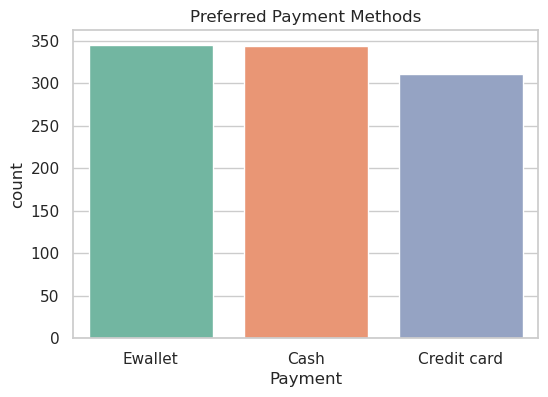

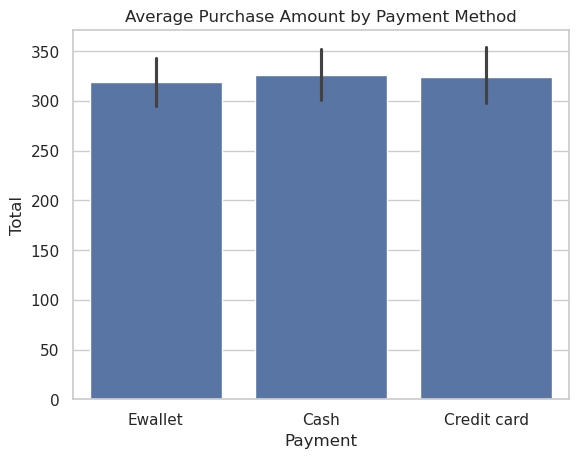

In [42]:
plt.figure(figsize=(6,4))
sns.countplot(x='Payment', data=df, order=df['Payment'].value_counts().index, palette="Set2")
plt.title("Preferred Payment Methods")
plt.show()

# Compare average total per payment type
sns.barplot(x='Payment', y='Total', data=df, estimator=np.mean)
plt.title("Average Purchase Amount by Payment Method")
plt.show()


/tmp/ipykernel_48380/2552100505.py:2: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




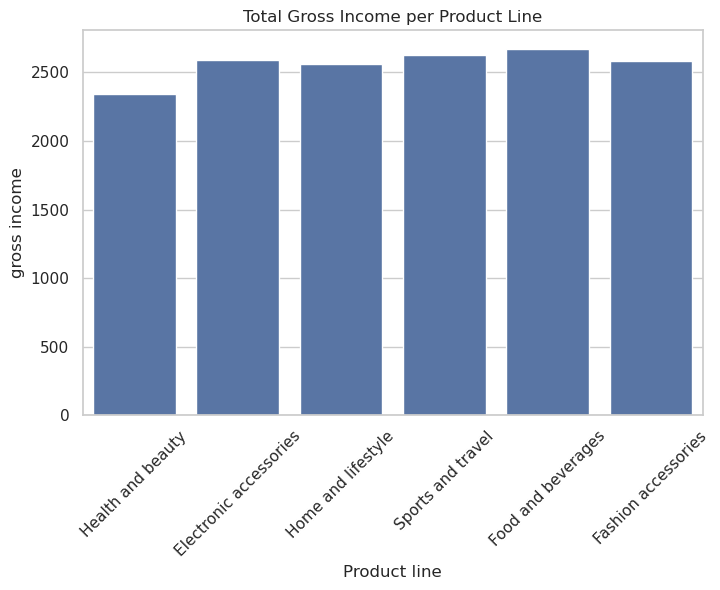

In [60]:
plt.figure(figsize=(8,5))
sns.barplot(x='Product line', y='gross income', data=df, estimator=sum, ci=None)
plt.title("Total Gross Income per Product Line")
plt.xticks(rotation=45)
plt.show()


In [58]:
# Interactive Visualization
import plotly.express as px
import plotly.graph_objects as go
branch_sales = df.groupby('Branch')['Total'].sum().reset_index()
fig = px.bar(branch_sales, x='Branch', y='Total', title="Total Sales per Branch", color='Branch')
fig.show(renderer="browser")



